In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf 
import tensorflow_datasets as tfds 

from tensorflow.keras import layers 

In [3]:
(train_ds, val_ds, test_ds), metadata = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\Nitro\tensorflow_datasets\tf_flowers\incomplete.O4055H_3.0.1\tf_flowers-train.tfrecord*...:…

Dataset tf_flowers downloaded and prepared to C:\Users\Nitro\tensorflow_datasets\tf_flowers\3.0.1. Subsequent calls will reuse this data.


In [4]:
num_classes=metadata.features['label'].num_classes
print(num_classes)

5


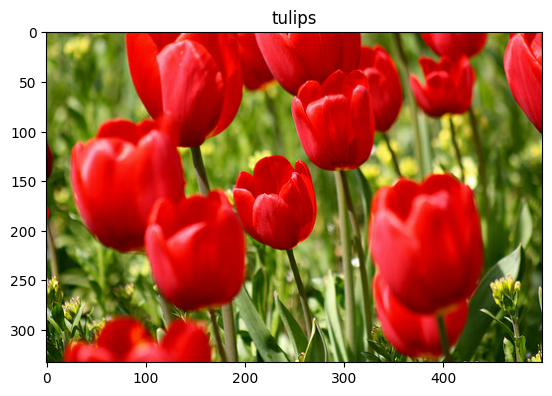

In [6]:
get_label_name=metadata.features['label'].int2str

image,label=next(iter(train_ds))
_ =plt.imshow(image)
_=plt.title(get_label_name(label))

### Using Keras Preprocessing layers

In [7]:
IMG_SIZE=100

resize_and_rescale=tf.keras.Sequential([
    layers.Resizing(IMG_SIZE,IMG_SIZE),
    layers.Rescaling(1./255)
])

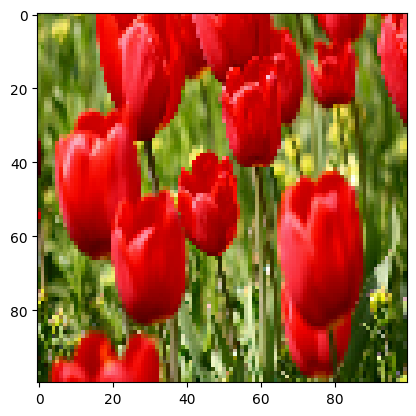

In [8]:
result=resize_and_rescale(image)
_=plt.imshow(result)

In [9]:
print("Min and Max pixel values:",result.numpy().min(), result.numpy().max())

Min and Max pixel values: 0.0 1.0


In [10]:
data_augementation=tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

### Add the image to a batch

In [12]:
image=tf.cast(tf.expand_dims(image,0),tf.float32)

In [ ]:
plt.figure(figsize=(10,10))
for i in range(9):
    augemented_image=data_augementation(image)
    ax=plt.subplot(3,3,i+1)
    plt.imshow(augemente